In [1]:
!pip install codecarbon scikit-learn pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 402.7/402.7 kB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 114.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 116.2 MB/s eta 0:00:00
  Attempting uninstall: psutil
    Found existing installation: psutil 5.9.5
    Uninstalling psutil-5.9.5:
      Successfully uninstalled psutil-5.9.5


In [1]:
import pandas as pd
import numpy as np
import time

from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

print("Setup successful!")

Setup successful!


In [2]:
# Load a real text dataset
data = fetch_20newsgroups(
    subset="all",
    categories=["sci.space", "rec.autos"],
    remove=("headers", "footers", "quotes")
)

X = data.data
y = data.target

print("Number of samples:", len(X))
print("Number of classes:", len(set(y)))
print("Classes:", data.target_names)

Number of samples: 1977
Number of classes: 2
Classes: ['rec.autos', 'sci.space']


In [3]:
# Split data once so both models use exactly the same data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Convert text into numerical TF-IDF features
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training samples:", X_train_tfidf.shape[0])
print("Test samples:", X_test_tfidf.shape[0])
print("Features:", X_train_tfidf.shape[1])

Training samples: 1581
Test samples: 396
Features: 5000


In [4]:
from codecarbon import EmissionsTracker

# Small model
small_model = LogisticRegression(max_iter=1000)

tracker = EmissionsTracker(
    project_name="GreenAI_Small_Model",
    measure_power_secs=1,
    save_to_file=False
)

start_time = time.time()

tracker.start()

small_model.fit(X_train_tfidf, y_train)

emissions_small = tracker.stop()

training_time_small = time.time() - start_time

pred_small = small_model.predict(X_test_tfidf)
accuracy_small = accuracy_score(y_test, pred_small)

print("SMALL MODEL RESULTS")
print("-------------------")
print("Accuracy:", round(accuracy_small * 100, 2), "%")
print("Training time:", round(training_time_small, 3), "seconds")
print("Estimated CO2:", round(emissions_small, 8), "kg")

[codecarbon WARNING @ 04:29:32] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 04:29:32] [setup] RAM Tracking...
[codecarbon INFO @ 04:29:32] [setup] CPU Tracking...
[codecarbon INFO @ 04:29:32] [setup] GPU Tracking...
[codecarbon INFO @ 04:29:32] Tracking Nvidia GPUs via PyNVML
[codecarbon WARNING @ 04:29:33] We saw that you have a Intel(R) Xeon(R) CPU @ 2.00GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 04:29:33] We will use the default power consumption of 4 W per thread for your 2 CPU, so 8W.
[codecarbon WARNING @ 04:29:33] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 04:29:33] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.00GHz
[codecarbon WARNING @ 04:29:33] No CPU tracking mode found. Falling back on CPU load mode.
[code

SMALL MODEL RESULTS
-------------------
Accuracy: 94.7 %
Training time: 2.037 seconds
Estimated CO2: 1.4e-07 kg


In [5]:
# Larger model
large_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

tracker = EmissionsTracker(
    project_name="GreenAI_Large_Model",
    measure_power_secs=1,
    save_to_file=False
)

start_time = time.time()

tracker.start()

large_model.fit(X_train_tfidf, y_train)

emissions_large = tracker.stop()

training_time_large = time.time() - start_time

pred_large = large_model.predict(X_test_tfidf)
accuracy_large = accuracy_score(y_test, pred_large)

print("LARGE MODEL RESULTS")
print("-------------------")
print("Accuracy:", round(accuracy_large * 100, 2), "%")
print("Training time:", round(training_time_large, 3), "seconds")
print("Estimated CO2:", round(emissions_large, 8), "kg")

[codecarbon WARNING @ 04:30:14] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 04:30:14] Monitoring GPUs with indices: [0] out of 1 total GPUs
[codecarbon INFO @ 04:30:14] >>> Tracker's metadata:
[codecarbon INFO @ 04:30:14]   Platform system: Linux-6.6.122+-x86_64-with-glibc2.39
[codecarbon INFO @ 04:30:14]   Python version: 3.13.15
[codecarbon INFO @ 04:30:14]   CodeCarbon version: 3.3.1
[codecarbon INFO @ 04:30:14]   Available RAM : 12.671 GB
[codecarbon INFO @ 04:30:14]   CPU count: 2 thread(s) in 1 physical CPU(s)
[codecarbon INFO @ 04:30:14]   CPU model: Intel(R) Xeon(R) CPU @ 2.00GHz
[codecarbon INFO @ 04:30:14]   GPU count: 1
[codecarbon INFO @ 04:30:14]   GPU model: 1 x Tesla T4
[codecarbon INFO @ 04:30:14] Energy consumed for RAM : 0.000000 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 04:30:14] Monitoring GPUs with indices: [0] out of 1 total GPUs
[codecarbon INFO @ 04:30:14] Energy consumed for all GPUs : 0.000000 kWh. Total GPU Power 

LARGE MODEL RESULTS
-------------------
Accuracy: 88.89 %
Training time: 2.596 seconds
Estimated CO2: 5.98e-06 kg


In [ ]:
# Larger model
large_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

tracker = EmissionsTracker(
    project_name="GreenAI_Large_Model",
    measure_power_secs=1,
    save_to_file=False
)

start_time = time.time()

tracker.start()

large_model.fit(X_train_tfidf, y_train)

emissions_large = tracker.stop()

training_time_large = time.time() - start_time

pred_large = large_model.predict(X_test_tfidf)
accuracy_large = accuracy_score(y_test, pred_large)

print("LARGE MODEL RESULTS")
print("-------------------")
print("Accuracy:", round(accuracy_large * 100, 2), "%")
print("Training time:", round(training_time_large, 3), "seconds")
print("Estimated CO2:", round(emissions_large, 8), "kg")

[codecarbon WARNING @ 04:30:14] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 04:30:14] Monitoring GPUs with indices: [0] out of 1 total GPUs
[codecarbon INFO @ 04:30:14] >>> Tracker's metadata:
[codecarbon INFO @ 04:30:14]   Platform system: Linux-6.6.122+-x86_64-with-glibc2.39
[codecarbon INFO @ 04:30:14]   Python version: 3.13.15
[codecarbon INFO @ 04:30:14]   CodeCarbon version: 3.3.1
[codecarbon INFO @ 04:30:14]   Available RAM : 12.671 GB
[codecarbon INFO @ 04:30:14]   CPU count: 2 thread(s) in 1 physical CPU(s)
[codecarbon INFO @ 04:30:14]   CPU model: Intel(R) Xeon(R) CPU @ 2.00GHz
[codecarbon INFO @ 04:30:14]   GPU count: 1
[codecarbon INFO @ 04:30:14]   GPU model: 1 x Tesla T4
[codecarbon INFO @ 04:30:14] Energy consumed for RAM : 0.000000 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 04:30:14] Monitoring GPUs with indices: [0] out of 1 total GPUs
[codecarbon INFO @ 04:30:14] Energy consumed for all GPUs : 0.000000 kWh. Total GPU Power 

LARGE MODEL RESULTS
-------------------
Accuracy: 88.89 %
Training time: 2.596 seconds
Estimated CO2: 5.98e-06 kg


In [6]:
results = []

for run in range(1, 4):

    # ---------- SMALL MODEL ----------
    small_model = LogisticRegression(max_iter=1000)

    tracker = EmissionsTracker(
        project_name=f"Small_Model_Run_{run}",
        measure_power_secs=1,
        save_to_file=False
    )

    start = time.time()
    tracker.start()

    small_model.fit(X_train_tfidf, y_train)

    emissions = tracker.stop()
    training_time = time.time() - start

    accuracy = accuracy_score(
        y_test,
        small_model.predict(X_test_tfidf)
    )

    results.append({
        "Run": run,
        "Model": "Logistic Regression",
        "Accuracy": accuracy * 100,
        "Training Time (s)": training_time,
        "CO2 (kg)": emissions
    })

    # ---------- LARGE MODEL ----------
    large_model = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

    tracker = EmissionsTracker(
        project_name=f"Large_Model_Run_{run}",
        measure_power_secs=1,
        save_to_file=False
    )

    start = time.time()
    tracker.start()

    large_model.fit(X_train_tfidf, y_train)

    emissions = tracker.stop()
    training_time = time.time() - start

    accuracy = accuracy_score(
        y_test,
        large_model.predict(X_test_tfidf)
    )

    results.append({
        "Run": run,
        "Model": "Random Forest",
        "Accuracy": accuracy * 100,
        "Training Time (s)": training_time,
        "CO2 (kg)": emissions
    })

results_df = pd.DataFrame(results)

results_df

[codecarbon WARNING @ 04:31:57] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 04:31:57] Monitoring GPUs with indices: [0] out of 1 total GPUs
[codecarbon INFO @ 04:31:57] >>> Tracker's metadata:
[codecarbon INFO @ 04:31:57]   Platform system: Linux-6.6.122+-x86_64-with-glibc2.39
[codecarbon INFO @ 04:31:57]   Python version: 3.13.15
[codecarbon INFO @ 04:31:57]   CodeCarbon version: 3.3.1
[codecarbon INFO @ 04:31:57]   Available RAM : 12.671 GB
[codecarbon INFO @ 04:31:57]   CPU count: 2 thread(s) in 1 physical CPU(s)
[codecarbon INFO @ 04:31:57]   CPU model: Intel(R) Xeon(R) CPU @ 2.00GHz
[codecarbon INFO @ 04:31:57]   GPU count: 1
[codecarbon INFO @ 04:31:57]   GPU model: 1 x Tesla T4
[codecarbon INFO @ 04:31:57] Energy consumed for RAM : 0.000000 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 04:31:57] Monitoring GPUs with indices: [0] out of 1 total GPUs
[codecarbon INFO @ 04:31:57] Energy consumed for all GPUs : 0.000000 kWh. Total GPU Power 

,Run,Model,Accuracy,Training Time (s),CO2 (kg)
0,1,Logistic Regression,94.696970,0.569135,5.165256e-07
1,1,Random Forest,88.888889,5.912638,1.722901e-05
2,2,Logistic Regression,94.696970,0.602746,4.809520e-07
3,2,Random Forest,88.888889,5.347797,1.543165e-05
4,3,Logistic Regression,94.696970,0.421139,2.865252e-07
5,3,Random Forest,88.888889,2.870811,7.028924e-06


In [7]:
# Calculate average results
summary = results_df.groupby("Model").agg({
    "Accuracy": "mean",
    "Training Time (s)": "mean",
    "CO2 (kg)": "mean"
}).reset_index()

print(summary)

# Extract values
small = summary[summary["Model"] == "Logistic Regression"].iloc[0]
large = summary[summary["Model"] == "Random Forest"].iloc[0]

accuracy_difference = small["Accuracy"] - large["Accuracy"]
time_increase = ((large["Training Time (s)"] / small["Training Time (s)"]) - 1) * 100
co2_increase = large["CO2 (kg)"] / small["CO2 (kg)"]

print("\n--- COMPARISON ---")
print("Accuracy difference:", round(accuracy_difference, 2), "percentage points")
print("Training time increase:", round(time_increase, 1), "%")
print("CO2 multiplier:", round(co2_increase, 1), "x")

                 Model   Accuracy  Training Time (s)      CO2 (kg)
0  Logistic Regression  94.696970           0.531007  4.280009e-07
1        Random Forest  88.888889           4.710416  1.322986e-05

--- COMPARISON ---
Accuracy difference: 5.81 percentage points
Training time increase: 787.1 %
CO2 multiplier: 30.9 x


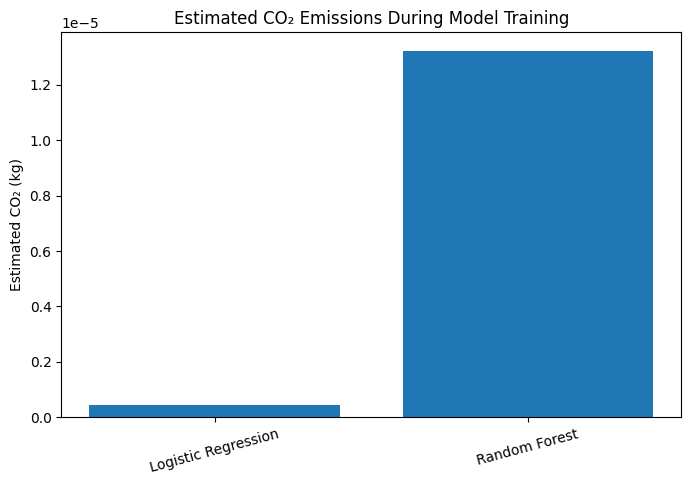

In [8]:
import matplotlib.pyplot as plt

models = summary["Model"]
co2 = summary["CO2 (kg)"]

plt.figure(figsize=(8,5))
plt.bar(models, co2)
plt.ylabel("Estimated CO₂ (kg)")
plt.title("Estimated CO₂ Emissions During Model Training")
plt.xticks(rotation=15)
plt.show()

In [10]:
# Save experiment results
results_df.to_csv("greenai_experiment_results.csv", index=False)

# Save averaged results
summary.to_csv("greenai_summary.csv", index=False)

print("Results saved successfully!")

Results saved successfully!


In [11]:
import os
import pickle

# Save both trained models
with open("logistic_regression_model.pkl", "wb") as f:
    pickle.dump(small_model, f)

with open("random_forest_model.pkl", "wb") as f:
    pickle.dump(large_model, f)

# Check model file sizes
small_size = os.path.getsize("logistic_regression_model.pkl") / (1024 * 1024)
large_size = os.path.getsize("random_forest_model.pkl") / (1024 * 1024)

print("Logistic Regression model size:", round(small_size, 3), "MB")
print("Random Forest model size:", round(large_size, 3), "MB")

Logistic Regression model size: 0.039 MB
Random Forest model size: 12.999 MB


In [12]:
import time
import numpy as np

def measure_inference(model, X, repetitions=10):
    times = []

    for _ in range(repetitions):
        start = time.perf_counter()
        model.predict(X)
        end = time.perf_counter()

        times.append(end - start)

    return np.mean(times), np.std(times)

small_inf_mean, small_inf_std = measure_inference(
    small_model, X_test_tfidf
)

large_inf_mean, large_inf_std = measure_inference(
    large_model, X_test_tfidf
)

print("INFERENCE RESULTS")
print("-----------------")
print("Logistic Regression:")
print("Average:", round(small_inf_mean, 6), "seconds")
print("Std:", round(small_inf_std, 6), "seconds")

print("\nRandom Forest:")
print("Average:", round(large_inf_mean, 6), "seconds")
print("Std:", round(large_inf_std, 6), "seconds")

INFERENCE RESULTS
-----------------
Logistic Regression:
Average: 0.000479 seconds
Std: 0.000349 seconds

Random Forest:
Average: 0.095906 seconds
Std: 0.003453 seconds


In [13]:
print("MODEL COMPLEXITY")
print("----------------")

# Logistic Regression
logistic_parameters = (
    small_model.coef_.size + small_model.intercept_.size
)

print("Logistic Regression parameters:", logistic_parameters)

# Random Forest
rf_trees = len(large_model.estimators_)

rf_nodes = sum(
    tree.tree_.node_count
    for tree in large_model.estimators_
)

print("Random Forest trees:", rf_trees)
print("Random Forest total nodes:", rf_nodes)

MODEL COMPLEXITY
----------------
Logistic Regression parameters: 5001
Random Forest trees: 300
Random Forest total nodes: 169184


In [14]:
day2_summary = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy (%)": [small["Accuracy"], large["Accuracy"]],
    "Training Time (s)": [small["Training Time (s)"], large["Training Time (s)"]],
    "CO2 (kg)": [small["CO2 (kg)"], large["CO2 (kg)"]],
    "Model Size (MB)": [small_size, large_size],
    "Inference Time (s)": [small_inf_mean, large_inf_mean],
    "Complexity": ["5,001 parameters", "300 trees / 169,184 nodes"]
})

day2_summary

,Model,Accuracy (%),Training Time (s),CO2 (kg),Model Size (MB),Inference Time (s),Complexity
0,Logistic Regression,94.696970,0.531007,4.280009e-07,0.038835,0.000479,"5,001 parameters"
1,Random Forest,88.888889,4.710416,1.322986e-05,12.998706,0.095906,"300 trees / 169,184 nodes"


In [15]:
day2_summary.to_csv("greenai_final_metrics.csv", index=False)

print("Day 2 metrics saved successfully!")

Day 2 metrics saved successfully!


In [17]:
# Compare the computational/environmental cost of the two models

lr = day2_summary.iloc[0]
rf = day2_summary.iloc[1]

print("GREENAI COMPARISON")
print("-" * 40)

print(f"Training time: Random Forest is {rf['Training Time (s)'] / lr['Training Time (s)']:.1f}× higher")
print(f"CO₂ estimate: Random Forest is {rf['CO2 (kg)'] / lr['CO2 (kg)']:.1f}× higher")
print(f"Inference time: Random Forest is {rf['Inference Time (s)'] / lr['Inference Time (s)']:.1f}× higher")
print(f"Saved model size: Random Forest is {rf['Model Size (MB)'] / lr['Model Size (MB)']:.1f}× larger")

print()
print(f"Accuracy difference: {lr['Accuracy (%)'] - rf['Accuracy (%)']:.2f} percentage points")

GREENAI COMPARISON
----------------------------------------
Training time: Random Forest is 8.9× higher
CO₂ estimate: Random Forest is 30.9× higher
Inference time: Random Forest is 200.2× higher
Saved model size: Random Forest is 334.7× larger

Accuracy difference: 5.81 percentage points


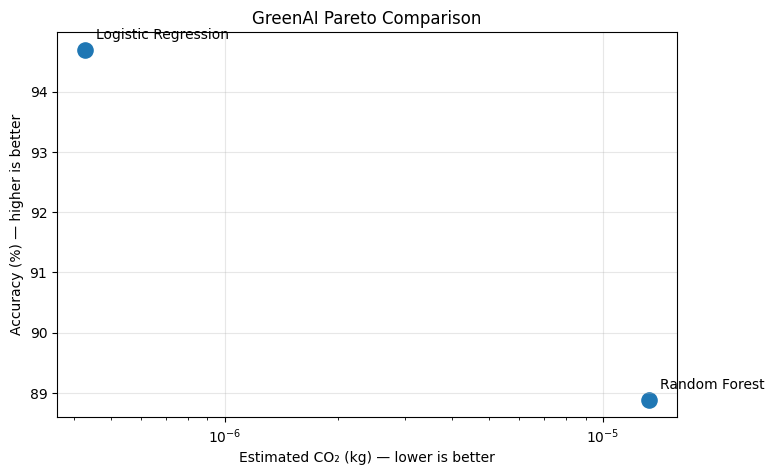

In [18]:
import matplotlib.pyplot as plt

models = day2_summary["Model"]
accuracy = day2_summary["Accuracy (%)"]
co2 = day2_summary["CO2 (kg)"]

plt.figure(figsize=(8, 5))

plt.scatter(co2, accuracy, s=120)

for i, model in enumerate(models):
    plt.annotate(
        model,
        (co2.iloc[i], accuracy.iloc[i]),
        xytext=(8, 8),
        textcoords="offset points"
    )

plt.xscale("log")
plt.xlabel("Estimated CO₂ (kg) — lower is better")
plt.ylabel("Accuracy (%) — higher is better")
plt.title("GreenAI Pareto Comparison")
plt.grid(True, alpha=0.3)

plt.show()

In [19]:
# GreenAI efficiency indicators

comparison = pd.DataFrame({
    "Model": day2_summary["Model"],
    "Accuracy (%)": day2_summary["Accuracy (%)"],
    "CO2 (kg)": day2_summary["CO2 (kg)"],
    "CO2 per Accuracy Point": (
        day2_summary["CO2 (kg)"] / day2_summary["Accuracy (%)"]
    ),
    "Inference Time per 100 Predictions (s)": (
        day2_summary["Inference Time (s)"] * 100
    )
})

comparison

,Model,Accuracy (%),CO2 (kg),CO2 per Accuracy Point,Inference Time per 100 Predictions (s)
0,Logistic Regression,94.696970,4.280009e-07,4.519690e-09,0.047902
1,Random Forest,88.888889,1.322986e-05,1.488360e-07,9.590623


In [20]:
greenai_profile = pd.DataFrame({
    "Model": day2_summary["Model"],
    "Accuracy (%)": day2_summary["Accuracy (%)"].round(2),
    "Training Time (s)": day2_summary["Training Time (s)"].round(3),
    "Estimated CO2 (kg)": day2_summary["CO2 (kg)"].apply(lambda x: f"{x:.2e}"),
    "Model Size (MB)": day2_summary["Model Size (MB)"].round(3),
    "Inference / prediction (s)": day2_summary["Inference Time (s)"].round(6),
    "CO2 / Accuracy Point": comparison["CO2 per Accuracy Point"].apply(lambda x: f"{x:.2e}")
})

greenai_profile

,Model,Accuracy (%),Training Time (s),Estimated CO2 (kg),Model Size (MB),Inference / prediction (s),CO2 / Accuracy Point
0,Logistic Regression,94.70,0.531,4.28e-07,0.039,0.000479,4.52e-09
1,Random Forest,88.89,4.710,1.32e-05,12.999,0.095906,1.49e-07


In [23]:
# Robustness test across different train/test splits

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import time

seeds = [7, 21, 42, 99, 123]

robustness_results = []

for seed in seeds:
    X_train_text, X_test_text, y_train, y_test = train_test_split(
        texts,
        y,
        test_size=0.20,
        random_state=seed,
        stratify=y
    )

    vectorizer_test = TfidfVectorizer(
        max_features=5000,
        stop_words="english"
    )

    X_train = vectorizer_test.fit_transform(X_train_text)
    X_test = vectorizer_test.transform(X_test_text)

    # Logistic Regression
    lr = LogisticRegression(max_iter=1000)

    start = time.time()
    lr.fit(X_train, y_train)
    lr_time = time.time() - start

    lr_accuracy = accuracy_score(y_test, lr.predict(X_test))

    # Random Forest
    rf = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

    start = time.time()
    rf.fit(X_train, y_train)
    rf_time = time.time() - start

    rf_accuracy = accuracy_score(y_test, rf.predict(X_test))

    robustness_results.append({
        "Seed": seed,
        "Logistic Accuracy (%)": lr_accuracy * 100,
        "Logistic Training Time (s)": lr_time,
        "Random Forest Accuracy (%)": rf_accuracy * 100,
        "Random Forest Training Time (s)": rf_time
    })

robustness_df = pd.DataFrame(robustness_results)

robustness_df

,Seed,Logistic Accuracy (%),Logistic Training Time (s),Random Forest Accuracy (%),Random Forest Training Time (s)
0,7,91.161616,0.015474,88.636364,2.229174
1,21,94.191919,0.021532,91.414141,5.832087
2,42,94.696970,0.089568,88.888889,4.221691
3,99,91.666667,0.020568,88.383838,2.239351
4,123,91.414141,0.015200,88.636364,3.330818


In [22]:
from sklearn.datasets import fetch_20newsgroups

categories = ["rec.autos", "sci.space"]

data = fetch_20newsgroups(
    subset="all",
    categories=categories,
    remove=("headers", "footers", "quotes")
)

texts = data.data
y = data.target

print("Total samples:", len(texts))
print("Number of classes:", len(set(y)))

Total samples: 1977
Number of classes: 2


In [24]:
robustness_summary = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Mean Accuracy (%)": [
        robustness_df["Logistic Accuracy (%)"].mean(),
        robustness_df["Random Forest Accuracy (%)"].mean()
    ],
    "Std Accuracy (%)": [
        robustness_df["Logistic Accuracy (%)"].std(),
        robustness_df["Random Forest Accuracy (%)"].std()
    ],
    "Mean Training Time (s)": [
        robustness_df["Logistic Training Time (s)"].mean(),
        robustness_df["Random Forest Training Time (s)"].mean()
    ],
    "Std Training Time (s)": [
        robustness_df["Logistic Training Time (s)"].std(),
        robustness_df["Random Forest Training Time (s)"].std()
    ]
})

robustness_summary

,Model,Mean Accuracy (%),Std Accuracy (%),Mean Training Time (s),Std Training Time (s)
0,Logistic Regression,92.626263,1.678866,0.032468,0.032049
1,Random Forest,89.191919,1.255028,3.570624,1.513884


In [25]:
lr_acc = robustness_summary.loc[0, "Mean Accuracy (%)"]
rf_acc = robustness_summary.loc[1, "Mean Accuracy (%)"]

lr_time = robustness_summary.loc[0, "Mean Training Time (s)"]
rf_time = robustness_summary.loc[1, "Mean Training Time (s)"]

print(f"Mean accuracy difference: {lr_acc - rf_acc:.2f} percentage points")
print(f"Random Forest training-time multiplier: {rf_time / lr_time:.1f}×")

Mean accuracy difference: 3.43 percentage points
Random Forest training-time multiplier: 110.0×


In [26]:
import time
import pandas as pd
from scipy.sparse import vstack

sample_sizes = [100, 1000, 10000]
scaling_results = []

for n in sample_sizes:

    # Reuse the test data to create the requested batch size
    repeats = (n // X_test.shape[0]) + 1
    X_batch = vstack([X_test] * repeats)[:n]

    # Logistic Regression
    start = time.perf_counter()
    lr.predict(X_batch)
    lr_time = time.perf_counter() - start

    # Random Forest
    start = time.perf_counter()
    rf.predict(X_batch)
    rf_time = time.perf_counter() - start

    scaling_results.append({
        "Samples": n,
        "Logistic Regression (s)": lr_time,
        "Random Forest (s)": rf_time,
        "RF / LR Time Ratio": rf_time / lr_time
    })

scaling_df = pd.DataFrame(scaling_results)

scaling_df

,Samples,Logistic Regression (s),Random Forest (s),RF / LR Time Ratio
0,100,0.000407,0.086658,212.722351
1,1000,0.000402,0.129561,322.531369
2,10000,0.001151,0.692296,601.369124


In [27]:
# Save all final experiment results

robustness_df.to_csv("greenai_robustness_results.csv", index=False)
robustness_summary.to_csv("greenai_robustness_summary.csv", index=False)
scaling_df.to_csv("greenai_inference_scaling.csv", index=False)
comparison.to_csv("greenai_efficiency_indicators.csv", index=False)

print("All GreenAI experiment results saved successfully!")


All GreenAI experiment results saved successfully!
